### Mini project: Noise modelling and restoration (code focused) 

**Your discussion must reference:** 
- noise models 
- filter selection rationale 
- trade offs between noise removal and detail preservation 

In [26]:
# setting up env
import numpy as np 
import matplotlib.pyplot as plt 
from skimage import data, util, exposure 
from scipy.ndimage import uniform_filter, median_filter 

### Start with a clean greyscale image & Add Gaussian noise

image shape: (500, 500), min: 29.67, max: 249.67, mean intensity: 118.66
image shape: (500, 500), min: 0.12, max: 0.98, mean intensity: 0.47


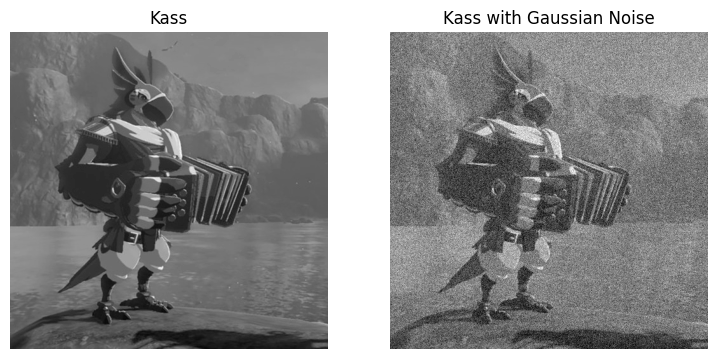

In [45]:
# read image and transform into gray scale
kass = plt.imread('./kass.jpg')
kass = kass.mean(axis=2)

# add gaussian noise 
sigma = 25
noise = np.random.default_rng(0).normal(0, sigma, kass.shape).astype(np.float32)
noise = noise + kass

# print image info 
print(f"image shape: {kass.shape}, min: {kass.min():.2f}, max: {kass.max():.2f}, mean intensity: {kass.mean():.2f}")

# change the range to [0,1]
kass = kass / 255
noise = noise /255

# clip ranges
noise = np.clip(noise, 0, 1)

# print again after changing the range 
print(f"image shape: {kass.shape}, min: {kass.min():.2f}, max: {kass.max():.2f}, mean intensity: {kass.mean():.2f}")


plt.figure(figsize=(9,6))
plt.subplot(1,2,1)
plt.title("Kass")
plt.imshow(kass, cmap='gray')
plt.axis('off')
#---
plt.subplot(1,2,2)
plt.title("Kass with Gaussian Noise")
plt.imshow(noise, cmap='gray')
plt.axis('off')
plt.show()

### Remove the noise using arithmetic mean and geometric mean filters

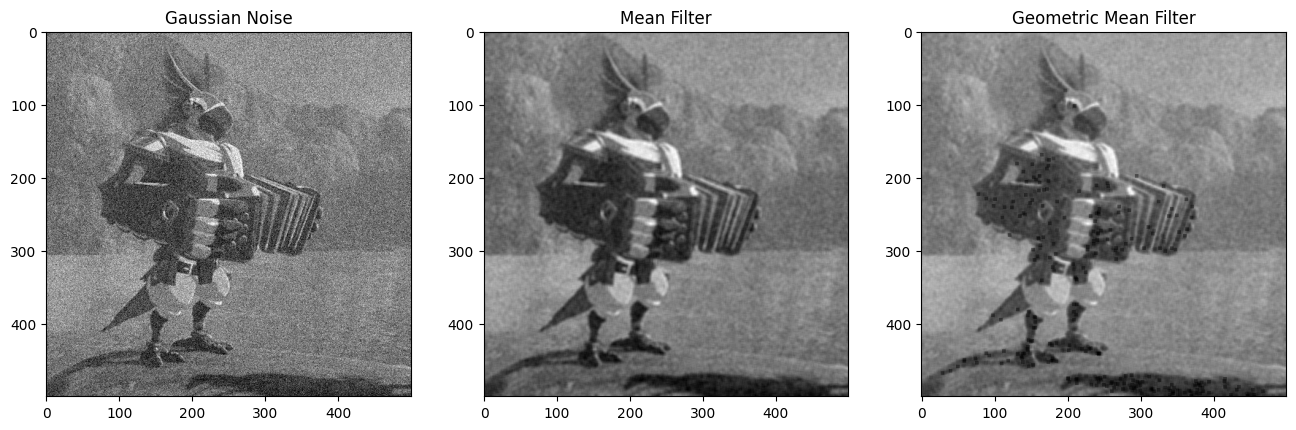

In [47]:
# mean filter
kass_mean = uniform_filter(noise, size=5)

# geo mean filter
def geometric_mean_filter(im, size=3, eps=1e-6): 
    # log-domain to avoid underflow 
    im2 = np.clip(im, eps, 1.0) 
    log_im = np.log(im2) 
    m = uniform_filter(log_im, size=size) 
    return np.exp(m) # because of the sigma of ln times the 1/mn so this makes it mean of the ln of pixels in the filter, so we take the exp so ln can go, remember the range in the image is 0,1
 
kass_geo = geometric_mean_filter(noise, size=5)

# display
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(noise, cmap='gray'); axes[0].set_title("Gaussian Noise")
axes[1].imshow(kass_mean, cmap='gray'); axes[1].set_title("Mean Filter")
axes[2].imshow(kass_geo, cmap='gray'); axes[2].set_title("Geometric Mean Filter")
plt.show()

### Add salt and pepper noise and remove it using median and contraharmonic filters

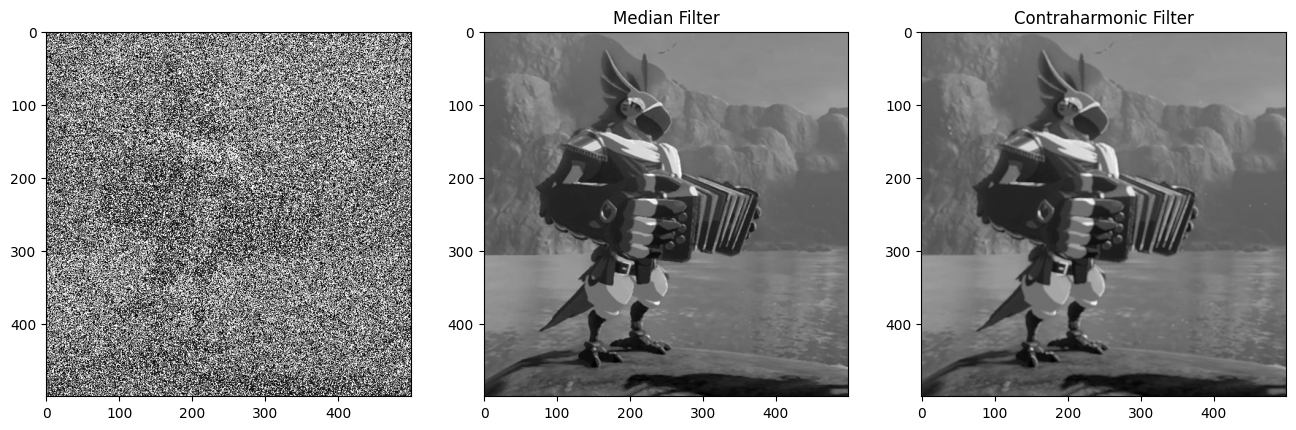

In [36]:
# add s&p noise 
sp = util.random_noise(kass, mode="s&p", amount=0.6).astype(np.float32)

# remove it using median filter 
kass_median_filtered = median_filter(kass, size=3)

# contraharmonic filter
from scipy.ndimage import generic_filter 
 
def contraharmonic(im, size=3, Q=1.5, eps=1e-6): 
    def f(window): 
        w = np.array(window, dtype=np.float32) 
        num = np.sum((w + eps) ** (Q + 1)) 
        den = np.sum((w + eps) ** Q) 
        return num / (den + eps) 
    return generic_filter(im, f, size=size) 

kass_contraharmonic = contraharmonic(kass)

# display
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(sp, cmap='gray'); axes[1].set_title("Salt & Pepper Noise")
axes[1].imshow(kass_median_filtered, cmap='gray'); axes[1].set_title("Median Filter")
axes[2].imshow(kass_contraharmonic, cmap='gray'); axes[2].set_title("Contraharmonic Filter")
plt.show()

### Compare results using both MSE and visual inspection.

**Starter evaluation:**
``` py
print("Gaussian noisy MSE:", mse(img, g)) 
print("Mean filter MSE:", mse(img, mean3)) 
print("Geometric mean MSE:", mse(img, geo3)) 
 
print("Impulse noisy MSE:", mse(img, sp)) 
print("Median filter MSE:", mse(img, med3)) 
```

In [51]:
def mse(kass, noise):
    return np.mean((kass - noise)**2)

print(f"Gaussian noisy MSE:{mse(kass, noise):.4f}") 
print(f"Mean filter MSE:{mse(kass, kass_mean):.4f}") 
print(f"Geometric mean MSE:{mse(kass, kass_geo):.4f}") 
 
print(f"Impulse noisy MSE:{mse(kass, sp):.4f}") 
print(f"Median filter MSE:{mse(kass, kass_median_filtered):.4f}") 

Gaussian noisy MSE:0.0096
Mean filter MSE:0.0011
Geometric mean MSE:0.0017
Impulse noisy MSE:0.1588
Median filter MSE:0.0001


 ### Reflection questions 
1. Why is restoration more objective than enhancement? 

A: Becasue it uses mathematical equations and to reduce noise and produce the closest image to the original one. This allow it to be used in machine prespective processes where restoration depend on the type of noise applied and exactly search for the suitable denoising equation. 

2. Why must noise models be identified before restoration? 

A: Identifying noise models will help us use the best process to apply denoising on (choose the most effective filter to use), which will produce the closest solutiono to the original image

3. Why is there no single best denoising filter?

A: because for each noiising technique there will be the perfect compement for it that will erase its effect completely, and thus types of noise are different, and one filter cannot fix them all